<a href="https://colab.research.google.com/github/Dina-Shanjida/fashionMNIST/blob/main/fashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [34]:
df = pd.read_csv('/content/sample_data/fmnist_small.csv')

In [3]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


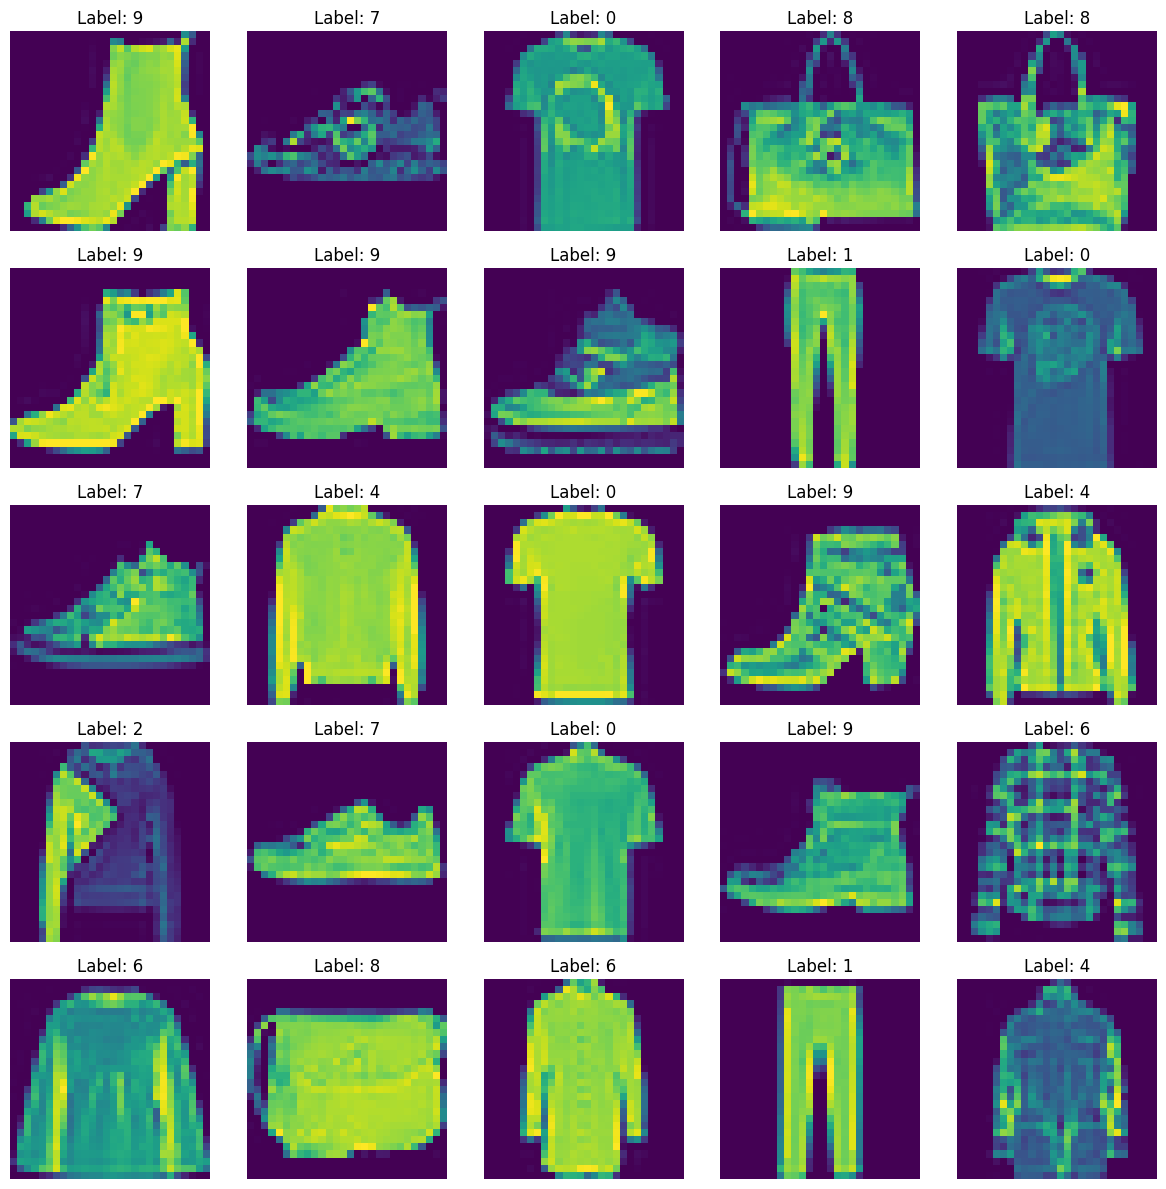

In [35]:
fig , axes = plt.subplots(5,5, figsize = (12 , 12))

for i, ax in enumerate(axes.flat):
  image = df.iloc[i, 1:].values.reshape(28 , 28)
  ax.imshow(image)
  ax.axis('off')
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout()
plt.show()

In [36]:


X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train/255.0
X_test = X_test/255.0


## custom dataset class

In [37]:
class CustomDataset(Dataset):
  def __init__( self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index], self.labels[index]

## dataset and dataloader

In [38]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

## model architecture

In [85]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),

        nn.Linear(128,64),
        nn.ReLU(),

        nn.Linear(64,10),

    )

  def forward(self,X):
    return self.model(X)


## model initialization

In [86]:
epochs = 50
learning_rate = 0.01
momentum = 0.9


model = MyNN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=learning_rate , momentum = momentum)

## model training

In [87]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:


    output = model(batch_features)
    loss = criterion(output,batch_labels)


    optimizer.zero_grad()
    loss.backward()


    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  print(f"epoch {epoch+1} loss = {total_epoch_loss/len(train_loader)}")





epoch 1 loss = 1.4505213030179342
epoch 2 loss = 0.7792240025599798
epoch 3 loss = 0.6403031863768895
epoch 4 loss = 0.5713094185789426
epoch 5 loss = 0.5282659823695819
epoch 6 loss = 0.4754859989881515
epoch 7 loss = 0.4566253772377968
epoch 8 loss = 0.43504706025123596
epoch 9 loss = 0.403629863311847
epoch 10 loss = 0.37968855410814284
epoch 11 loss = 0.35707662016153335
epoch 12 loss = 0.34177424157659214
epoch 13 loss = 0.32895909970005355
epoch 14 loss = 0.3147079580028852
epoch 15 loss = 0.30659781185289225
epoch 16 loss = 0.3049437361458937
epoch 17 loss = 0.2659333178400993
epoch 18 loss = 0.2851578680674235
epoch 19 loss = 0.25361401843527953
epoch 20 loss = 0.25966506481170654
epoch 21 loss = 0.23777619376778603
epoch 22 loss = 0.2241881493975719
epoch 23 loss = 0.21996206132074198
epoch 24 loss = 0.21672122187912465
epoch 25 loss = 0.21466038164993126
epoch 26 loss = 0.18928556494414805
epoch 27 loss = 0.18860346864908933
epoch 28 loss = 0.1827270659059286
epoch 29 loss = 

## model evaluation

In [91]:
model.eval()

total = 0
correct = 0


with torch.no_grad():
  for batch_features,batch_labels in train_loader:
    outputs = model(batch_features)

    _,predicted = torch.max(outputs,1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted==batch_labels).sum().item()


print(f"Training accuracy = {correct/total}")


Training accuracy = 0.9783333333333334


In [92]:
model.eval()

total = 0
correct = 0


with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    outputs = model(batch_features)

    _,predicted = torch.max(outputs,1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted==batch_labels).sum().item()


print(f"Testing accuracy = {correct/total}")


Testing accuracy = 0.8358333333333333
